In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.patches as mpatches

sns.set_theme(style="whitegrid")  # Clean, professional look
sns.set_context("notebook")  # Good for general use, try "paper" or "poster" too

In [2]:
from pyexcel_ods3 import get_data
import json

In [3]:
def read_ods_as_nested_dict(filename):

    data = get_data(filename)
    sheet_data = data['Sheet1']
    
    # FIXED: Strip spaces from headers
    headers = [header.strip() if isinstance(header, str) else header 
               for header in sheet_data[0][1:]]  # Skip first empty header
    
    result = {}
    current_operation = None
    
    for row in sheet_data[1:]:
        if not row or all(x is None or x == '' for x in row):
            continue
            
        if row[0] is not None and row[0] != '':
            current_operation = row[0]
        
        if current_operation not in result:
            result[current_operation] = {}
        
        # Get vector length and block size
        vector_length = row[1] if len(row) > 1 else None
        block_size = row[2] if len(row) > 2 else None
        
        if vector_length not in result[current_operation]:
            result[current_operation][vector_length] = {}
        
        # Store all metrics for this combination
        metrics = {}
        for i, header in enumerate(headers[2:], 3):  # Skip vector_length and block_size
            if i < len(row):
                # FIXED: Use stripped header as key
                metrics[header] = row[i]
        
        result[current_operation][vector_length][block_size] = metrics
    
    return result

In [4]:
agner_pmc_haswell = read_ods_as_nested_dict('../measurement/agner_measurement_table_haswell_Vec8f.ods')
agner_pmc_skylake = read_ods_as_nested_dict('../measurement/agner_measurement_table_skylake_Vec8f.ods')
agner_pmc_meteorlake = read_ods_as_nested_dict('../measurement/agner_measurement_table_meteorlake_Vec8f.ods')

In [5]:
agner_pmc_haswell.keys()

dict_keys(['permute', 'depermute', 'fir cores', 'part sol', 'homo sol', 'cr forward', 'cr backward', 'iir ph', 'iir cr', 'block filtering', 'scalar', 'filter ph 2', 'filter ph 4', 'filter ph 8', 'filter ph 16', 'filter cr 2', 'filter cr 4', 'filter cr 8', 'filter cr 16', 'filter bf 2', 'filter bf 4', 'filter bf 8', 'filter bf 16', 'filter sc 2', 'filter sc 4', 'filter sc 8', 'filter sc 16'])

In [6]:
agner_pmc_haswell['permute'][8][8]
agner_pmc_haswell['permute'][4][16]

{'data size': 64,
 'cyc': 42,
 'inst': 82,
 'uops': 99,
 'rs': 0,
 'rs std': 0,
 'cm': 0,
 'cm std': 0,
 'cdm': 0,
 'cdm std': 0,
 'cps': 0.65625,
 'ips': 1.28125,
 'ipc': 1.9523809523809523,
 'rss': 0}

In [7]:
f_ph2_pmc_haswell = agner_pmc_haswell['filter ph 2'][8]

f_ph2_cps_haswell = np.array([metrics['cps'] for metrics in f_ph2_pmc_haswell.values()])

In [8]:
f_ph4_pmc_haswell = agner_pmc_haswell['filter ph 4'][8]

f_ph4_cps_haswell = np.array([metrics['cps'] for metrics in f_ph4_pmc_haswell.values()])

In [9]:
f_ph8_pmc_haswell = agner_pmc_haswell['filter ph 8'][8]

f_ph8_cps_haswell = np.array([metrics['cps'] for metrics in f_ph8_pmc_haswell.values()])

In [10]:
f_ph16_pmc_haswell = agner_pmc_haswell['filter ph 16'][8]

f_ph16_cps_haswell = np.array([metrics['cps'] for metrics in f_ph16_pmc_haswell.values()])

In [11]:
f_ph2_pmc_skylake = agner_pmc_skylake['filter ph 2'][8]

f_ph2_cps_skylake = np.array([metrics['cps'] for metrics in f_ph2_pmc_skylake.values()])

In [12]:
f_ph4_pmc_skylake = agner_pmc_skylake['filter ph 4'][8]

f_ph4_cps_skylake = np.array([metrics['cps'] for metrics in f_ph4_pmc_skylake.values()])

In [13]:
f_ph8_pmc_skylake = agner_pmc_skylake['filter ph 8'][8]

f_ph8_cps_skylake = np.array([metrics['cps'] for metrics in f_ph8_pmc_skylake.values()])

In [14]:
f_ph16_pmc_skylake = agner_pmc_skylake['filter ph 16'][8]

f_ph16_cps_skylake = np.array([metrics['cps'] for metrics in f_ph16_pmc_skylake.values()])

In [15]:
f_ph2_pmc_meteorlake = agner_pmc_meteorlake['filter ph 2'][8]

f_ph2_cps_meteorlake = np.array([metrics['cps'] for metrics in f_ph2_pmc_meteorlake.values()])

In [16]:
f_ph4_pmc_meteorlake = agner_pmc_meteorlake['filter ph 4'][8]

f_ph4_cps_meteorlake = np.array([metrics['cps'] for metrics in f_ph4_pmc_meteorlake.values()])

In [17]:
f_ph8_pmc_meteorlake = agner_pmc_meteorlake['filter ph 8'][8]

f_ph8_cps_meteorlake = np.array([metrics['cps'] for metrics in f_ph8_pmc_meteorlake.values()])

In [18]:
f_ph16_pmc_meteorlake = agner_pmc_meteorlake['filter ph 16'][8]

f_ph16_cps_meteorlake = np.array([metrics['cps'] for metrics in f_ph16_pmc_meteorlake.values()])

In [19]:
f_cr2_pmc_haswell = agner_pmc_haswell['filter cr 2'][8]

f_cr2_cps_haswell = np.array([metrics['cps'] for metrics in f_cr2_pmc_haswell.values()])

In [20]:
f_cr4_pmc_haswell = agner_pmc_haswell['filter cr 4'][8]

f_cr4_cps_haswell = np.array([metrics['cps'] for metrics in f_cr4_pmc_haswell.values()])

In [21]:
f_cr8_pmc_haswell = agner_pmc_haswell['filter cr 8'][8]

f_cr8_cps_haswell = np.array([metrics['cps'] for metrics in f_cr8_pmc_haswell.values()])

In [22]:
f_cr16_pmc_haswell = agner_pmc_haswell['filter cr 16'][8]

f_cr16_cps_haswell = np.array([metrics['cps'] for metrics in f_cr16_pmc_haswell.values()])

In [23]:
f_cr2_pmc_skylake = agner_pmc_skylake['filter cr 2'][8]

f_cr2_cps_skylake = np.array([metrics['cps'] for metrics in f_cr2_pmc_skylake.values()])

In [24]:
f_cr4_pmc_skylake = agner_pmc_skylake['filter cr 4'][8]

f_cr4_cps_skylake = np.array([metrics['cps'] for metrics in f_cr4_pmc_skylake.values()])

In [25]:
f_cr8_pmc_skylake = agner_pmc_skylake['filter cr 8'][8]

f_cr8_cps_skylake = np.array([metrics['cps'] for metrics in f_cr8_pmc_skylake.values()])

In [26]:
f_cr16_pmc_skylake = agner_pmc_skylake['filter cr 16'][8]

f_cr16_cps_skylake = np.array([metrics['cps'] for metrics in f_cr16_pmc_skylake.values()])

In [27]:
f_cr2_pmc_meteorlake = agner_pmc_meteorlake['filter cr 2'][8]

f_cr2_cps_meteorlake = np.array([metrics['cps'] for metrics in f_cr2_pmc_meteorlake.values()])

In [28]:
f_cr4_pmc_meteorlake = agner_pmc_meteorlake['filter cr 4'][8]

f_cr4_cps_meteorlake = np.array([metrics['cps'] for metrics in f_cr4_pmc_meteorlake.values()])

In [29]:
f_cr8_pmc_meteorlake = agner_pmc_meteorlake['filter cr 8'][8]

f_cr8_cps_meteorlake = np.array([metrics['cps'] for metrics in f_cr8_pmc_meteorlake.values()])

In [30]:
f_cr16_pmc_meteorlake = agner_pmc_meteorlake['filter cr 16'][8]

f_cr16_cps_meteorlake = np.array([metrics['cps'] for metrics in f_cr16_pmc_meteorlake.values()])

In [31]:
L = 8
N = 2**np.arange(3,9)
N

array([  8,  16,  32,  64, 128, 256])

In [32]:
N = np.array([64,128,256,512,1024,2048])

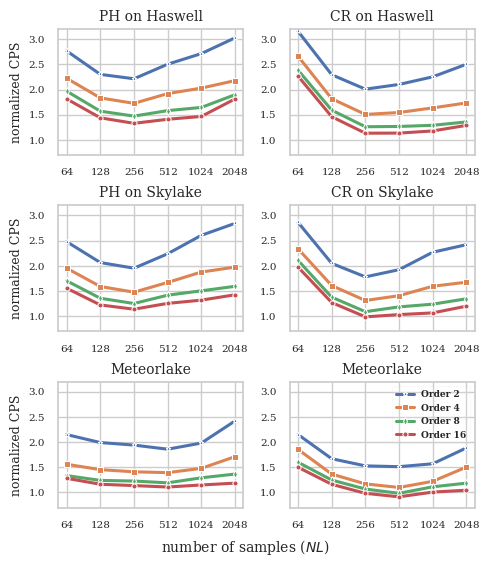

In [33]:
# Set seaborn style and font properties
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 7.5,
    'ytick.labelsize': 7.5,
    'legend.fontsize': 9
})

default_palette = sns.color_palette()
blue = default_palette[0]    # Default blue (first color)
orange = default_palette[1]  # Default orange (second color)
green = default_palette[2]   # Default green (third color)
red = default_palette[3]     # Default red (fourth color)

# Create 6x2 subplot layout
# fig, ((ax1, ax2,ax9), (ax3, ax4,ax10), (ax5, ax6,ax11)) = plt.subplots(3, 3, figsize=(9, 7))
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(5, 5.5))
N_ticks = np.arange(len(N))

# First row: Haswell Architecture - Filter Order Comparison
# First subplot: PH Method CPS comparison on Haswell
sns.lineplot(x=N_ticks, y=f_ph2_cps_haswell[:-1], marker='*', label='PH Order 2', linewidth=2.2, ax=ax1, legend=False, markersize=3.7)
sns.lineplot(x=N_ticks, y=f_ph4_cps_haswell[:-1]/2, marker='s', label='PH Order 4', linewidth=2.2, ax=ax1, legend=False, markersize=3.7)
sns.lineplot(x=N_ticks, y=f_ph8_cps_haswell[:-1]/4, marker='d', label='PH Order 8', linewidth=2.2, ax=ax1, legend=False, markersize=3.7)
sns.lineplot(x=N_ticks, y=f_ph16_cps_haswell[:-1]/8, marker='o', label='PH Order 16', linewidth=2.2, ax=ax1, legend=False, markersize=3.7)

ax1.set_xticks(N_ticks)
ax1.set_xticklabels(N)
# ax1.set_xlabel('Number of Blocks (N)')
# ax1.set_ylabel('Cycles per Sample')
# ax1.set_title('Haswell Architecture - PH Method CPS by Filter Order')
ax1.set_title('PH on Haswell')
ax1.set_ylim(0.7,3.2)
# legend1 = ax1.legend(framealpha=0.9, fontsize=8)
# legend1.get_frame().set_alpha(0.8)

# Second subplot: CR Method CPS comparison on Haswell
sns.lineplot(x=N_ticks, y=f_cr2_cps_haswell[:-1], marker='*', label='CR Order 2', linewidth=2.2, ax=ax2, legend=False, markersize=3.7)
sns.lineplot(x=N_ticks, y=f_cr4_cps_haswell[:-1]/2, marker='s', label='CR Order 4', linewidth=2.2, ax=ax2, legend=False, markersize=3.7)
sns.lineplot(x=N_ticks, y=f_cr8_cps_haswell[:-1]/4, marker='d', label='CR Order 8', linewidth=2.2, ax=ax2, legend=False, markersize=3.7)
sns.lineplot(x=N_ticks, y=f_cr16_cps_haswell[:-1]/8, marker='o', label='CR Order 16', linewidth=2.2, ax=ax2, legend=False, markersize=3.7)
ax2.set_xticks(N_ticks)
ax2.set_xticklabels(N)
# ax2.set_xlabel('Number of Blocks (N)')
# ax2.set_ylabel('Cycles per Sample')
ax2.set_title('CR on Haswell')
ax2.set_ylim(0.7,3.2)
# legend2 = ax2.legend(framealpha=0.9, fontsize=8)
# legend2.get_frame().set_alpha(0.8)

# Second row: Skylake Architecture - Filter Order Comparison
# Third subplot: PH Method CPS comparison on Skylake
sns.lineplot(x=N_ticks, y=f_ph2_cps_skylake[:-1], marker='*', label='PH Order 2', linewidth=2.2, ax=ax3, legend=False, markersize=3.7)
sns.lineplot(x=N_ticks, y=f_ph4_cps_skylake[:-1]/2, marker='s', label='PH Order 4', linewidth=2.2, ax=ax3, legend=False, markersize=3.7)
sns.lineplot(x=N_ticks, y=f_ph8_cps_skylake[:-1]/4, marker='d', label='PH Order 8', linewidth=2.2, ax=ax3, legend=False, markersize=3.7)
sns.lineplot(x=N_ticks, y=f_ph16_cps_skylake[:-1]/8, marker='o', label='PH Order 16', linewidth=2.2, ax=ax3, legend=False, markersize=3.7)
ax3.set_xticks(N_ticks)
ax3.set_xticklabels(N)
# ax3.set_xlabel('Number of Blocks (N)')
# ax3.set_ylabel('Cycles per Sample')
ax3.set_title('PH on Skylake')
ax3.set_ylim(0.7,3.2)
# legend3 = ax3.legend(framealpha=0.9, fontsize=8)
# legend3.get_frame().set_alpha(0.8)

# Fourth subplot: CR Method CPS comparison on Skylake
sns.lineplot(x=N_ticks, y=f_cr2_cps_skylake[:-1], marker='*', label='CR Order 2', linewidth=2.2, ax=ax4, legend=False, markersize=3.7)
sns.lineplot(x=N_ticks, y=f_cr4_cps_skylake[:-1]/2, marker='s', label='CR Order 4', linewidth=2.2, ax=ax4, legend=False, markersize=3.7)
sns.lineplot(x=N_ticks, y=f_cr8_cps_skylake[:-1]/4, marker='d', label='CR Order 8', linewidth=2.2, ax=ax4, legend=False, markersize=3.7)
sns.lineplot(x=N_ticks, y=f_cr16_cps_skylake[:-1]/8, marker='o', label='CR Order 16', linewidth=2.2, ax=ax4, legend=False, markersize=3.7)
ax4.set_xticks(N_ticks)
ax4.set_xticklabels(N)
# ax4.set_xlabel('Number of Blocks (N)')
# ax4.set_ylabel('Cycles per Sample')
ax4.set_title('CR on Skylake')
ax4.set_ylim(0.7,3.2)
# legend4 = ax4.legend(framealpha=0.9, fontsize=8)
# legend4.get_frame().set_alpha(0.8)

# Third row: Meteor Lake Architecture - Filter Order Comparison
# Fifth subplot: PH Method CPS comparison on Meteor Lake
sns.lineplot(x=N_ticks, y=f_ph2_cps_meteorlake, marker='*', label='Normalized CPS, Order 2', linewidth=2.2, ax=ax5, legend=False, markersize=3.7)
sns.lineplot(x=N_ticks, y=f_ph4_cps_meteorlake/2, marker='s', label='Normalized CPS, Order 4', linewidth=2.2, ax=ax5, legend=False, markersize=3.7)
sns.lineplot(x=N_ticks, y=f_ph8_cps_meteorlake/4, marker='d', label='Normalized CPS, Order 8', linewidth=2.2, ax=ax5, legend=False, markersize=3.7)
sns.lineplot(x=N_ticks, y=f_ph16_cps_meteorlake/8, marker='o', label='Normalized CPS, Order 16', linewidth=2.2, ax=ax5, legend=False, markersize=3.7)
ax5.set_xticks(N_ticks)
ax5.set_xticklabels(N)
# ax5.set_xlabel('Number of Blocks (N)')
# ax5.set_ylabel('Cycles per Sample')
ax5.set_title('Meteorlake')
ax5.set_ylim(0.7,3.2)
# legend5 = ax5.legend(framealpha=0.9, fontsize=7,loc='upper center')
# legend5.get_frame().set_alpha(0.8)
# for text in legend5.get_texts():
#     text.set_fontweight('bold')

# Sixth subplot: CR Method CPS comparison on Meteor Lake
sns.lineplot(x=N_ticks, y=f_cr2_cps_meteorlake, marker='*', label='Order 2', linewidth=2.2, ax=ax6,  markersize=3.7)
sns.lineplot(x=N_ticks, y=f_cr4_cps_meteorlake/2, marker='s', label='Order 4', linewidth=2.2, ax=ax6,  markersize=3.7)
sns.lineplot(x=N_ticks, y=f_cr8_cps_meteorlake/4, marker='d', label='Order 8', linewidth=2.2, ax=ax6,  markersize=3.7)
sns.lineplot(x=N_ticks, y=f_cr16_cps_meteorlake/8, marker='o', label='Order 16', linewidth=2.2, ax=ax6,  markersize=3.7)
ax6.set_xticks(N_ticks)
ax6.set_xticklabels(N)
# ax6.set_xlabel('Number of Blocks (N)')
# ax6.set_ylabel('Cycles per Sample')
ax6.set_title('Meteorlake')
ax6.set_ylim(0.7,3.2)
# legend6 = ax6.legend(framealpha=0.9, fontsize=8)
# legend6.get_frame().set_alpha(0.8)
legend6 = ax6.legend(framealpha=0.9, fontsize=6.5,loc='upper right')
legend6.get_frame().set_alpha(0.1)
for text in legend6.get_texts():
    text.set_fontweight('bold')

ax1.set_ylabel('normalized CPS')
ax3.set_ylabel('normalized CPS')
ax5.set_ylabel('normalized CPS')


# # Fifth row: Method Comparison - PH vs CR on Haswell and Skylake
# # Ninth subplot: PH vs CR Order 16 on Haswell
# sns.lineplot(x=N_ticks, y=f_ph16_cps_haswell[:-1]/8, marker='o', color=red, label='Normalized CPS, PH Order 16', linewidth=2.2, ax=ax9, markersize=3.7)
# sns.lineplot(x=N_ticks, y=f_cr16_cps_haswell[:-1]/8, marker='o', color=red, label='Normalized CPS, CR Order 16', linewidth=2.2, ax=ax9, markersize=3.7,alpha=0.6)
# ax9.set_xticks(N_ticks)
# ax9.set_xticklabels(N)
# # ax9.set_xlabel('Number of Blocks (N)')
# # ax9.set_ylabel('Cycles per Sample')
# ax9.set_title('Haswell')
# ax9.set_ylim(0.7,3.2)
# legend9 = ax9.legend(framealpha=0.9, fontsize=7,loc='upper center')
# legend9.get_frame().set_alpha(0.8)
# for text in legend9.get_texts():
#     text.set_fontweight('bold')

# # Tenth subplot: PH vs CR Order 16 on Skylake
# sns.lineplot(x=N_ticks, y=f_ph16_cps_skylake[:-1]/8, marker='o', color=red, label='Normalized CPS, PH Order 16', linewidth=2.2, ax=ax10, markersize=3.7,legend=False)
# sns.lineplot(x=N_ticks, y=f_cr16_cps_skylake[:-1]/8, marker='o', color=red,  label='Normalized CPS, CR Order 16', linewidth=2.2, ax=ax10, markersize=3.7,legend=False,alpha=0.6)
# ax10.set_xticks(N_ticks)
# ax10.set_xticklabels(N)
# # ax10.set_xlabel('Number of Blocks (N)')
# # ax10.set_ylabel('Cycles per Sample')
# ax10.set_title('Skylake')
# ax10.set_ylim(0.7,3.2)
# # legend10 = ax10.legend(framealpha=0.9, fontsize=8)
# # legend10.get_frame().set_alpha(0.8)

# # Sixth row: Method Comparison - PH vs CR on Meteor Lake
# # Eleventh subplot: PH vs CR Order 16 on Meteor Lake
# sns.lineplot(x=N_ticks, y=f_ph16_cps_meteorlake/8, marker='o', color=red, label='Normalized CPS, PH Order 16', linewidth=2.2, ax=ax11, markersize=3.7,legend=False)
# sns.lineplot(x=N_ticks, y=f_cr16_cps_meteorlake/8, marker='o', color=red,  label='Normalized CPS, CR Order 16', linewidth=2.2, ax=ax11, markersize=3.7,legend=False,alpha=0.6)
# ax11.set_xticks(N_ticks)
# ax11.set_xticklabels(N)
# # ax11.set_xlabel('Number of Blocks (N)')
# # ax11.set_ylabel('Cycles per Sample')
# ax11.set_title('Meteorlake')
# ax11.set_ylim(0.7,3.2)
# # legend11 = ax11.legend(framealpha=0.9, fontsize=8)
# # legend11.get_frame().set_alpha(0.8)

# # Add a placeholder for the last subplot (ax12) or remove it if not needed
# # ax12.axis('off')  # Hide the unused subplot

plt.tight_layout()
plt.subplots_adjust(wspace=0.25, hspace=0.4)  # Added hspace for subtitle spacing


# fig.text(0.51, -0.02, 'Function Size (NL)', ha='center',  va='bottom',fontsize=11)

# # Common title for column 1 (Performance Rate)
# fig.text(0.28, 1, 'PH Factorization', ha='center', va='bottom', 
#          fontsize=11)

# # Common title for column 2 (Pipeline Efficiency)  
# fig.text(0.76, 1, 'Cyclic Reduction', ha='center', va='bottom',
#          fontsize=11)

fig.text(0.5, -0.005, 'number of samples ($NL$)', ha='center', va='center', fontsize=10)

# # Common title for column 1 (Performance Rate)
# fig.text(0.84, 1, 'PH vs. CR', ha='center', va='bottom', 
#          fontsize=11)
# plt.savefig('plot3.jpg', bbox_inches='tight', dpi=300, facecolor='white', edgecolor='none')

plt.show()

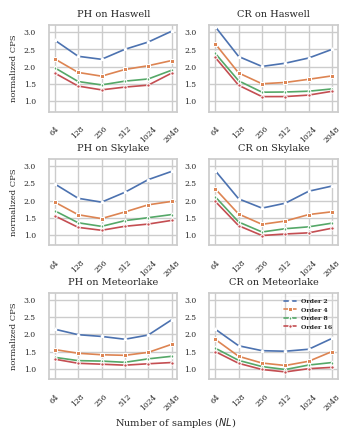

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Set seaborn style and font properties
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 6,
    'axes.titlesize': 7,
    'axes.labelsize': 6,
    'xtick.labelsize': 5.5,
    'ytick.labelsize': 5.5,
    'legend.fontsize': 5
})

default_palette = sns.color_palette()
blue = default_palette[0]
orange = default_palette[1]
green = default_palette[2]
red = default_palette[3]

fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(3.5, 4.2))
N_ticks = np.arange(len(N))

# ===================== Row 1: Haswell =====================
sns.lineplot(x=N_ticks, y=f_ph2_cps_haswell[:-1], marker='*', label='PH Order 2', linewidth=1.2, ax=ax1, legend=False, markersize=2.5)
sns.lineplot(x=N_ticks, y=f_ph4_cps_haswell[:-1]/2, marker='s', label='PH Order 4', linewidth=1.2, ax=ax1, legend=False, markersize=2.5)
sns.lineplot(x=N_ticks, y=f_ph8_cps_haswell[:-1]/4, marker='d', label='PH Order 8', linewidth=1.2, ax=ax1, legend=False, markersize=2.5)
sns.lineplot(x=N_ticks, y=f_ph16_cps_haswell[:-1]/8, marker='o', label='PH Order 16', linewidth=1.2, ax=ax1, legend=False, markersize=2.5)
ax1.set_xticks(N_ticks)
ax1.set_xticklabels(N, rotation=45, ha='center')
ax1.set_title('PH on Haswell')
ax1.set_ylim(0.7, 3.2)
ax1.set_ylabel('normalized CPS')

sns.lineplot(x=N_ticks, y=f_cr2_cps_haswell[:-1], marker='*', label='CR Order 2', linewidth=1.2, ax=ax2, legend=False, markersize=2.5)
sns.lineplot(x=N_ticks, y=f_cr4_cps_haswell[:-1]/2, marker='s', label='CR Order 4', linewidth=1.2, ax=ax2, legend=False, markersize=2.5)
sns.lineplot(x=N_ticks, y=f_cr8_cps_haswell[:-1]/4, marker='d', label='CR Order 8', linewidth=1.2, ax=ax2, legend=False, markersize=2.5)
sns.lineplot(x=N_ticks, y=f_cr16_cps_haswell[:-1]/8, marker='o', label='CR Order 16', linewidth=1.2, ax=ax2, legend=False, markersize=2.5)
ax2.set_xticks(N_ticks)
ax2.set_xticklabels(N, rotation=45, ha='center')
ax2.set_title('CR on Haswell')
ax2.set_ylim(0.7, 3.2)

# ===================== Row 2: Skylake =====================
sns.lineplot(x=N_ticks, y=f_ph2_cps_skylake[:-1], marker='*', label='PH Order 2', linewidth=1.2, ax=ax3, legend=False, markersize=2.5)
sns.lineplot(x=N_ticks, y=f_ph4_cps_skylake[:-1]/2, marker='s', label='PH Order 4', linewidth=1.2, ax=ax3, legend=False, markersize=2.5)
sns.lineplot(x=N_ticks, y=f_ph8_cps_skylake[:-1]/4, marker='d', label='PH Order 8', linewidth=1.2, ax=ax3, legend=False, markersize=2.5)
sns.lineplot(x=N_ticks, y=f_ph16_cps_skylake[:-1]/8, marker='o', label='PH Order 16', linewidth=1.2, ax=ax3, legend=False, markersize=2.5)
ax3.set_xticks(N_ticks)
ax3.set_xticklabels(N, rotation=45, ha='center')
ax3.set_title('PH on Skylake')
ax3.set_ylim(0.7, 3.2)
ax3.set_ylabel('normalized CPS')

sns.lineplot(x=N_ticks, y=f_cr2_cps_skylake[:-1], marker='*', label='CR Order 2', linewidth=1.2, ax=ax4, legend=False, markersize=2.5)
sns.lineplot(x=N_ticks, y=f_cr4_cps_skylake[:-1]/2, marker='s', label='CR Order 4', linewidth=1.2, ax=ax4, legend=False, markersize=2.5)
sns.lineplot(x=N_ticks, y=f_cr8_cps_skylake[:-1]/4, marker='d', label='CR Order 8', linewidth=1.2, ax=ax4, legend=False, markersize=2.5)
sns.lineplot(x=N_ticks, y=f_cr16_cps_skylake[:-1]/8, marker='o', label='CR Order 16', linewidth=1.2, ax=ax4, legend=False, markersize=2.5)
ax4.set_xticks(N_ticks)
ax4.set_xticklabels(N, rotation=45, ha='center')
ax4.set_title('CR on Skylake')
ax4.set_ylim(0.7, 3.2)

# ===================== Row 3: Meteor Lake =====================
sns.lineplot(x=N_ticks, y=f_ph2_cps_meteorlake, marker='*', label='Normalized CPS, Order 2', linewidth=1.2, ax=ax5, legend=False, markersize=2.5)
sns.lineplot(x=N_ticks, y=f_ph4_cps_meteorlake/2, marker='s', label='Normalized CPS, Order 4', linewidth=1.2, ax=ax5, legend=False, markersize=2.5)
sns.lineplot(x=N_ticks, y=f_ph8_cps_meteorlake/4, marker='d', label='Normalized CPS, Order 8', linewidth=1.2, ax=ax5, legend=False, markersize=2.5)
sns.lineplot(x=N_ticks, y=f_ph16_cps_meteorlake/8, marker='o', label='Normalized CPS, Order 16', linewidth=1.2, ax=ax5, legend=False, markersize=2.5)
ax5.set_xticks(N_ticks)
ax5.set_xticklabels(N, rotation=45, ha='center')
ax5.set_title('PH on Meteorlake')
ax5.set_ylim(0.7, 3.2)
ax5.set_ylabel('normalized CPS')

sns.lineplot(x=N_ticks, y=f_cr2_cps_meteorlake, marker='*', label='Order 2', linewidth=1.2, ax=ax6, markersize=2.5)
sns.lineplot(x=N_ticks, y=f_cr4_cps_meteorlake/2, marker='s', label='Order 4', linewidth=1.2, ax=ax6, markersize=2.5)
sns.lineplot(x=N_ticks, y=f_cr8_cps_meteorlake/4, marker='d', label='Order 8', linewidth=1.2, ax=ax6, markersize=2.5)
sns.lineplot(x=N_ticks, y=f_cr16_cps_meteorlake/8, marker='o', label='Order 16', linewidth=1.2, ax=ax6, markersize=2.5)
ax6.set_xticks(N_ticks)
ax6.set_xticklabels(N, rotation=45, ha='center')
ax6.set_title('CR on Meteorlake')
ax6.set_ylim(0.7, 3.2)
legend6 = ax6.legend(framealpha=0.9, fontsize=4.5, loc='upper right')
legend6.get_frame().set_alpha(0.1)
for text in legend6.get_texts():
    text.set_fontweight('bold')

plt.tight_layout()
plt.subplots_adjust(wspace=0.25, hspace=0.55)

fig.text(0.5, -0.005, 'Number of samples ($NL$)', ha='center', va='center', fontsize=7)

plt.savefig('../plot/plot3.png', bbox_inches='tight', dpi=600, facecolor='white', edgecolor='none')
plt.show()